# 演示一下动态断点的使用

## 涉及的新玩意儿
- interrupt函数: 利用抛出异常中断当前节点的执行
- as_node: graph.update_statede的参数之一,再次执行图时不再重新运行当前中断节点,而是直接进入下一个节点

In [1]:
from langchain_openai import ChatOpenAI


llm = ChatOpenAI(
    model="glm-4.7",
    api_key="d1de7475090740ebb6c887167a6a8b98.2WUSfYbmgQwYLKF4",
    base_url="https://open.bigmodel.cn/api/paas/v4/",  # 智谱OpenAI兼容地址，末尾斜杠不能丢
)

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


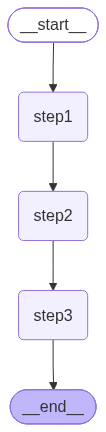

In [19]:
from typing import TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.types import interrupt
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display,Image
class State(TypedDict):
    input:str

def step_1(state:State)-> State:
    print("step 1 execute")
    return state

def check_input_len(state:State)->State:
    print("executen len check")
    if len(state["input"]) > 5:
        interrupt("len too long")

    return state


def step_finnal(state:State)->State:
    print("step3 ok")
    return state

graph = StateGraph(State)
graph.add_node("step1", step_1)
graph.add_node("step2", check_input_len)
graph.add_node("step3", step_finnal)

graph.add_edge(START, "step1")
graph.add_edge("step1", "step2")
graph.add_edge("step2", "step3")
graph.add_edge("step3",END)


checkpointer = MemorySaver()

app = graph.compile(checkpointer=checkpointer)

display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
# 测试并运行图
initial_input = {"input": "hello,world"}
thread_config = {"configurable": {"thread_id": "1"}}

for event in app.stream(initial_input, thread_config , stream_mode="values"):
    print(event)

{'input': 'hello,world'}

step 1 execute

{'input': 'hello,world'}

executen len check

{
    'input': 'hello,world',
    '__interrupt__': (Interrupt(value='len too long', id='53aa5ac4bc08fc3daa484156e782d859'),)
}

In [21]:
from rich import print

curr_state = app.get_state(thread_config)
print(curr_state)

StateSnapshot(
    values={'input': 'hello,world'},
    next=('step2',),
    config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f19f8c4-4106-6002-8001-ba648a9b67a1'
        }
    },
    metadata={'source': 'loop', 'step': 1, 'parents': {}},
    created_at='2026-08-24T07:20:21.135753+00:00',
    parent_config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f19f8c4-40f3-6004-8000-aa23619c0e22'
        }
    },
    tasks=(
        PregelTask(
            id='0c25da63-110b-7860-e0a5-cd01e0ecd431',
            name='step2',
            path=('__pregel_pull', 'step2'),
            error=None,
            interrupts=(Interrupt(value='len too long', id='53aa5ac4bc08fc3daa484156e782d859'),),
            state=None,
            result=None
        ),
    ),
    interrupts=(Interrupt(value='len too long', id='53aa5ac4bc08fc3daa484156e782d859'),)
)

In [23]:
# 尝试恢复执行(失败)
for event in app.stream(None, thread_config, stream_mode="values"):
    print(event)

{'input': 'hello,world'}

executen len check

{
    'input': 'hello,world',
    '__interrupt__': (Interrupt(value='len too long', id='53aa5ac4bc08fc3daa484156e782d859'),)
}

In [26]:
# 修改状态以通过中断节点
app.update_state(thread_config,{"input":"hello,wooo"}, as_node="step2")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f19f8c6-f095-65f8-8003-e4d835cf75d7'}}

In [27]:
for event in app.stream(None, thread_config, stream_mode="values"):
    print(event)

{'input': 'hello,wooo'}

step3 ok

{'input': 'hello,wooo'}